<a href="https://colab.research.google.com/github/Wai-Fun/Healthcare-Data-Analytics/blob/main/Readmission_Prediction_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Predicting Readmission Risk with Logistic Regression**

## Overview
Predicting 30-day hospital readmission is a common applied machine-learning task in healthcare. Logistic regression provides a transparent, interpretable baseline model. This lab focuses on end-to-end workflow: data simulation, preprocessing, model training, evaluation, calibration, and reporting—emphasizing interpretability and clinical relevance.

## Objectives
- Prepare clinical tabular data for binary classification (readmission yes/no).
- Train, evaluate, and interpret a logistic regression model for readmission risk.
- Handle class imbalance, perform feature preprocessing, and compute performance metrics (ROC, AUC, precision/recall).
- Use calibration plots and decision thresholds to support clinical decision-making.
- Report model performance with clarity for clinicians, including limitations and fairness checks.

## About the dataset/environment
- The simulate dataset contained the following columns: `patient_id`, `age`, `sex`, `comorbidity_count`, `length_of_stay`, `num_prior_admissions`, `lab_abnormal_flag`, `discharge_destination` (Home/SNF), and `readmitted_30d` (0/1).
- The simulated dataset will include moderate class imbalance (readmission ~15%).
- Tools: Python (pandas, numpy, scikit-learn, matplotlib, seaborn, imbalanced-learn optional).



###0. Setup

In [ ]:
!pip -q install numpy pandas scikit-learn matplotlib seaborn imbalanced-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, precision_recall_curve, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from imblearn.over_sampling import RandomOverSampler

# Reproducibility
RNG = np.random.default_rng(42)
np.random.seed(42)
pd.set_option('display.max_columns', 60)
sns.set(style='whitegrid')
print('Setup complete')

Setup complete


**Simulated 30-day dataset**: The generator constructs clinically meaningful predictors such as age, comorbidities, prior admissions, and discharge status, then assigns readmission probabilities using a controlled logistic process. This ensures a realistic, well-behaved dataset for experimenting with preprocessing steps and model evaluation techniques.

In [ ]:
# Simulate 30-day readmission dataset
def simulate_readmission(n_patients=2000, readmit_rate=0.15):
    ids = [f"P{10000+i}" for i in range(n_patients)]
    age = np.clip(np.random.normal(65, 14, size=n_patients).astype(int), 18, 95)
    sex = np.random.choice(['M','F'], size=n_patients, p=[0.52,0.48])
    comorbidity_count = np.random.poisson(2, size=n_patients)
    length_of_stay = np.clip(np.random.exponential(4, size=n_patients).astype(int)+1, 1, 60)
    num_prior_adm = np.random.poisson(1, size=n_patients)
    lab_abnormal_flag = np.random.binomial(1, 0.18, size=n_patients)
    discharge_destination = np.random.choice(['Home','SNF'], size=n_patients, p=[0.85,0.15])
    # base log-odds
    logits = -2.0 + 0.02*(age-65) + 0.4*lab_abnormal_flag + 0.25*(comorbidity_count) + 0.08*(length_of_stay) + 0.3*(discharge_destination=='SNF') + 0.15*(num_prior_adm)
    probs = 1/(1+np.exp(-logits))
    # calibrate to achieve approx readmit_rate
    probs = probs * (readmit_rate / probs.mean())
    probs = np.clip(probs, 0.01, 0.9)
    readmitted = np.random.binomial(1, probs)
    df = pd.DataFrame({
        'patient_id': ids,
        'age': age,
        'sex': sex,
        'comorbidity_count': comorbidity_count,
        'length_of_stay': length_of_stay,
        'num_prior_admissions': num_prior_adm,
        'lab_abnormal_flag': lab_abnormal_flag,
        'discharge_destination': discharge_destination,
        'readmitted_30d': readmitted
    })
    return df

df = simulate_readmission(n_patients=2000, readmit_rate=0.15)
df.head()


,patient_id,age,sex,comorbidity_count,length_of_stay,num_prior_admissions,lab_abnormal_flag,discharge_destination,readmitted_30d
0,P10000,71,M,3,3,2,0,Home,0
1,P10001,63,M,2,4,0,0,Home,0
2,P10002,74,M,6,8,0,1,Home,0
3,P10003,86,M,1,7,1,0,Home,0
4,P10004,61,F,2,1,0,0,Home,0


###1. Inspect and Understand Class Balance

In [ ]:
print('Rows, Columns:', df.shape)
print(df.dtypes)
df.describe().T
print('\nReadmission counts:\n', df['readmitted_30d'].value_counts(normalize=False))
print('\nReadmission rate:', df['readmitted_30d'].mean())

Rows, Columns: (2000, 9)
patient_id               object
age                       int64
sex                      object
comorbidity_count         int64
length_of_stay            int64
num_prior_admissions      int64
lab_abnormal_flag         int64
discharge_destination    object
readmitted_30d            int64
dtype: object

Readmission counts:
 readmitted_30d
0    1670
1     330
Name: count, dtype: int64

Readmission rate: 0.165


In [ ]:
# Missing Value check
df.isnull().sum()

,0
patient_id,0
age,0
sex,0
comorbidity_count,0
length_of_stay,0
num_prior_admissions,0
lab_abnormal_flag,0
discharge_destination,0
readmitted_30d,0


In [ ]:
# Duplicated row check
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1995,False
1996,False
1997,False
1998,False


###Data Transformation Pipeline (Scaling and Encoding)
This is a general-purpose feature preparation pipeline, use for models such as Logistic Regression, Linear Regression, Support Vector Machine (SVM), K-Nearest Neighbors (KNN), and Neural Networks; Might not necessary but helpful for Decision Tress, Random Forest and XGBoost/ GB, when there is need to create a consistent workflow, for model comparison, for cleaner producion code.

In [ ]:
# Preprocessing setup
numeric_features = ['age','comorbidity_count','length_of_stay','num_prior_admissions']
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

categorical_features = ['sex','discharge_destination','lab_abnormal_flag']
# lab_abnormal_flag is binary but treat as categorical for one-hot simplicity
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(drop='first'))])
# use drop= 'first' to remove redundancy in column 'sed' and 'lab_abnormal_flag', and prevent multicolinearlity

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

This code block means: scale the numberical data between -1 and 1; this will prevent the column with higher value skew the data; the categorical data is encoded using onehot encoder, that turn data into number 0,1,2; the preprocessor is an pbject that combine both the scaling and encoding.

###3. Train/Test split and Baseline Logistic Regression

Note for myself: The reason to drop the 'paitent_ID'. 1. Privacy reason; 2. ID contain no clinical signal but can harm model generalization.  

In [ ]:
# Train/test split
X = df.drop(columns=['patient_id','readmitted_30d'])
y = df['readmitted_30d']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42) # stratify=y is to preserve the class proportion

# Baseline logistic regression with class weight to handle imbalance
clf = Pipeline(steps=[('preprocessor', preprocessor),
                      ('clf', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42))])
# Train a Model
model = clf.fit(X_train, y_train)
print('Model trained.')

Model trained.


This code block: defined the X and Y values, and split them into train/test, and define model/test size. The pipeline method build start with preprocessing and then model into Regression model, and the fit the model witht the dataset to train it.

###4. Evaluate Model- ROC, AUC, Confusion Matrix, Precision-Recall and classification report

AUC: 0.632


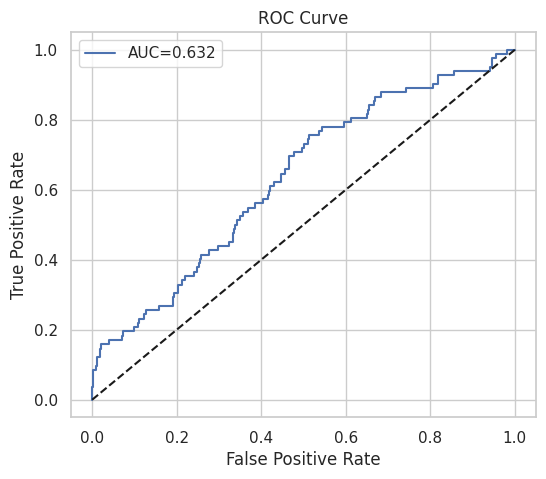

Confusion matrix (0.5 threshold):
 [[242 176]
 [ 33  49]]

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.58      0.70       418
           1       0.22      0.60      0.32        82

    accuracy                           0.58       500
   macro avg       0.55      0.59      0.51       500
weighted avg       0.77      0.58      0.64       500



In [ ]:
# Predictions and probabilities
y_prob = model.predict_proba(X_test)[:,1]
y_pred = model.predict(X_test)

# ROC and AUC
auc = roc_auc_score(y_test, y_prob)
print('AUC:', round(auc,3))
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC={auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


# Confusion matrix at 0.5 threshold
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix (0.5 threshold):\n', cm)
print('\nClassification report:\n', classification_report(y_test, y_pred))

**Result Interpretation**

**ROC curve & AUC:** The ROC curve shows the model performs better than random guessing, with modest ability (AUC = 0.632) to distinguish readmitted from non-readmitted patients. (AUC=0.5 indicate random ranking)

**Confusion Matrix:**

**Clssification Report:**
- Class 1, precision = 0.22: Of all patients predicted as readmitted, only 22% actually were readmitted. Many flase readmission alert.
- Class 1, recall =0.60: The model detected 60% of truly readmitted patients.
- Class 1, f1-score =0.32: Weak overall minority-class performance





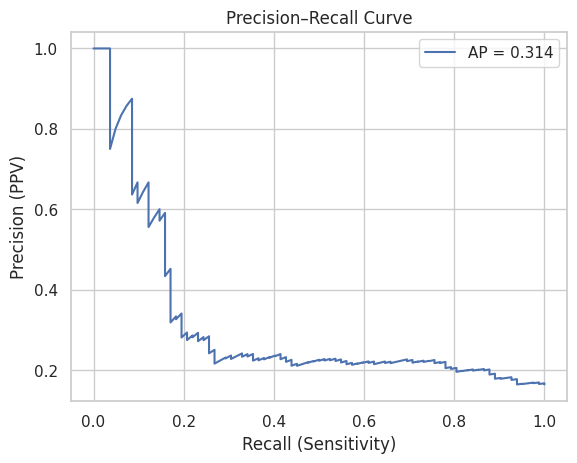

In [ ]:
# Precision-Recall curve
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

plt.figure()
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision (PPV)")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()

PR-curve: The model's top-ranked prediction are quite reliable (y close to 1); but as soon as you try to capture more positives, you start pulling in many false positive, and the ranking quality deteriorate quickly.

###5. Calibration and Thresholding

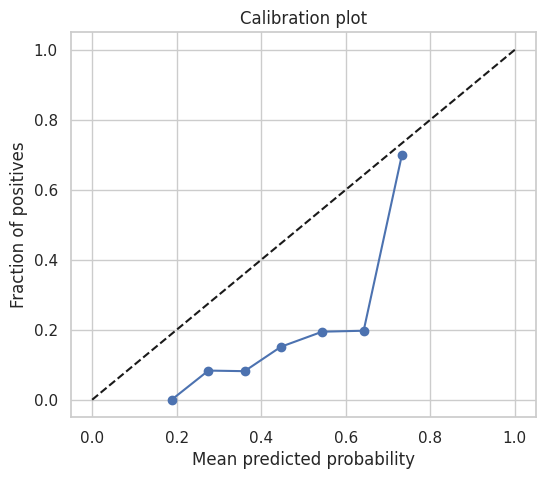

Threshold 0.2: PPV=0.164, Sensitivity=1.000
Threshold 0.3: PPV=0.168, Sensitivity=0.976
Threshold 0.4: PPV=0.191, Sensitivity=0.878
Threshold 0.5: PPV=0.218, Sensitivity=0.598


In [ ]:
# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration plot')
plt.show()

# Explore different thresholds
thresholds = [0.2, 0.3, 0.4, 0.5]
for t in thresholds:
    pred_t = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_t).ravel()
    ppv = tp/(tp+fp) if (tp+fp)>0 else 0
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    print(f'Threshold {t}: PPV={ppv:.3f}, Sensitivity={sens:.3f}')

Calibration curve: the curve is below the diagonal indicate overconfident. The output probablility should not be use as it, but could be a food scoring function.

at Threshold 0.2, sensitivity is high (able to catch everyone) but PPV is low (lots of false alarm);
at Threshold 0.5, sensitivity is low (I'll miss many real cases); but higher PPV indicate fewer false alarm.

###6. Address Imbalance (Oversampling) and compare

In [ ]:
# Oversampling training set
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train, y_train)
print('Resampled class distribution:', pd.Series(y_res).value_counts())

clf_res = Pipeline(steps=[('preprocessor', preprocessor),
                      ('clf', LogisticRegression(solver='liblinear', random_state=42))])
model_res = clf_res.fit(X_res, y_res)
y_prob_res = model_res.predict_proba(X_test)[:,1]
print('AUC (resampled train):', round(roc_auc_score(y_test, y_prob_res),3))

Resampled class distribution: readmitted_30d
0    1252
1    1252
Name: count, dtype: int64
AUC (resampled train): 0.627


Oversampling did not improve performance because it only duplicates existing rare cases and does not add new clinical information. The model was already handling imbalance through class weights, so results remained stable.

In [ ]:
# Classification After Oversampling:

# Confusion matrix at 0.5 threshold
y_pred = model_res.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix (0.5 threshold):\n', cm)
print('\nClassification report:\n', classification_report(y_test, y_pred))

Confusion matrix (0.5 threshold):
 [[252 166]
 [ 35  47]]

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.60      0.71       418
           1       0.22      0.57      0.32        82

    accuracy                           0.60       500
   macro avg       0.55      0.59      0.52       500
weighted avg       0.77      0.60      0.65       500



After oversampling, there is slight imporvement for class 0 (non-readmission), but slighlt worsening of class 1 (re-admission/ target group). -- fewer True Positive, and more false negative.

In this exercise, oversampling did NOT improve minority/readmission/target class detection.

Various possible reasons:
1. The problem is not just class imbalance, the model is likely.to be limited by feature quality, weak signical in predictors, and linear model limitations.
2. The model is stable.
3. The oversampling only duplicate data, it does not add new information.

###7. Interpretation and Reporting

In [ ]:
# Coefficients interpretation
feature_names_num = numeric_features
# get one-hot feature names
ohe = model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
ohe_features = list(ohe.get_feature_names_out(['sex','discharge_destination','lab_abnormal_flag']))
feature_names = list(feature_names_num) + ohe_features
coefs = model.named_steps['clf'].coef_[0]
coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})
coef_df['odds_ratio'] = np.exp(coef_df['coef'])
coef_df.sort_values('coef', ascending=False).reset_index(drop=True)

,feature,coef,odds_ratio
0,age,0.359257,1.432264
1,comorbidity_count,0.264674,1.303007
2,length_of_stay,0.126358,1.134689
3,lab_abnormal_flag_1,0.054735,1.056261
4,sex_M,0.023198,1.023469
5,discharge_destination_Home,-0.003204,0.996801
6,discharge_destination_SNF,-0.009686,0.990361
7,num_prior_admissions,-0.013653,0.986439
8,sex_F,-0.036089,0.964555
9,lab_abnormal_flag_0,-0.067626,0.934610


In [ ]:
clean_names = [name.replace("num__", "")
                    .replace("cat__", "")
               for name in feature_names]

coefs = model.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({
    "feature": clean_names,
    "coef": coefs
})

coef_df["odds_ratio"] = np.exp(coef_df["coef"])
coef_df = coef_df.sort_values("odds_ratio", ascending=False)

coef_df["interpretation"] = coef_df["odds_ratio"].apply(
    lambda x: "↑ risk" if x > 1 else "↓ risk"
)

coef_df

,feature,coef,odds_ratio,interpretation
0,age,0.359257,1.432264,↑ risk
1,comorbidity_count,0.264674,1.303007,↑ risk
2,length_of_stay,0.126358,1.134689,↑ risk
9,lab_abnormal_flag_1,0.054735,1.056261,↑ risk
5,sex_M,0.023198,1.023469,↑ risk
6,discharge_destination_Home,-0.003204,0.996801,↓ risk
7,discharge_destination_SNF,-0.009686,0.990361,↓ risk
3,num_prior_admissions,-0.013653,0.986439,↓ risk
4,sex_F,-0.036089,0.964555,↓ risk
8,lab_abnormal_flag_0,-0.067626,0.934610,↓ risk


In [ ]:
# Important Note. Age (OR = 1.43 per 1 standard deviation increase)
one_SD_age = df['age'].std()

print(f"A ~{one_SD_age:.0f}-year increase in age (one standard deviation) is associated with a 43% higher odds of 30-day readmission.")

A ~14-year increase in age (one standard deviation) is associated with a 43% higher odds of 30-day readmission.


Clinical Summary:

- Patients with higher age and more medical conditions are more likely to be readmitted within 30 days.

- Longer hospital stays also slightly increase readmission risk.

- Other factors such as sex, lab results, and discharge destination have much smaller effects in this model.

- Overall, the model mainly identifies sicker and more medically complex patients as higher risk.